# PREPROCESSING PIPELINE — Waste Classification Dataset

**Căn cứ từ EDA:**
- 20.700 ảnh, 256×256 PNG, RGB, 8 class
- **5.423 ảnh trùng (~26%)** → ưu tiên số 1 cần xử lý
- **Imbalance 7.12×** (Plastic 5692 vs Textiles 800)
- Domain shift DS1(studio) vs DS2(thực tế), F=59 ANOVA về brightness
- Background phức tạp ở tất cả class → nguy cơ học nhầm background
- Màu sắc có tính phân biệt cao → **KHÔNG gray-scale**
- Paper có outlier complexity min=5.54 (giấy trắng nền trắng)

---
**Pipeline gồm 4 bước:**
1. Advanced Cleaning (dedup + blur + low-content)
2. Image Transformation (resize + normalize)
3. Feature Extraction (HOG + Color Histogram + CNN embeddings)
4. Xử lý Class Imbalance (Augmentation + class weights)

In [35]:
# ═══════════════════════════════════════════════
# IMPORT & CONFIG
# ═══════════════════════════════════════════════
import os
import hashlib
import shutil
import random
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import cv2
from tqdm.auto import tqdm

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# Feature extraction
from skimage.feature import hog
from skimage import exposure

# Augmentation (Albumentations)
ALBU_AVAILABLE = False
ALBU_TORCH_AVAILABLE = False
A = None
ToTensorV2 = None
try:
    import albumentations as A
    ALBU_AVAILABLE = True
    try:
        from albumentations.pytorch import ToTensorV2
        ALBU_TORCH_AVAILABLE = True
    except Exception:
        ToTensorV2 = None
        ALBU_TORCH_AVAILABLE = False
        print("Albumentations pytorch transforms unavailable - ToTensorV2 disabled.")
except Exception:
    A = None
    print("Albumentations not available - augmentation will use PIL fallback.")

# Deep learning (optional - for CNN feature extraction)
try:
    import torch
    import torchvision.transforms as T
    import torchvision.models as models
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False
    print("PyTorch khong kha dung — bo qua CNN feature extraction")

random.seed(42)
np.random.seed(42)

# ── Đường dẫn ──────────────────────────────────
DATA_DIR   = Path('Merged_Dataset/train')
CLEAN_DIR  = Path('Cleaned_Dataset/train')   # Output sau cleaning
FEAT_DIR   = Path('Features')                # Output features
AUG_DIR    = Path('Augmented_Dataset/train') # Output augmentation

fallback_dir = Path('train')
if not DATA_DIR.exists():
    if fallback_dir.exists():
        print(f"[WARN] {DATA_DIR} not found, fallback to {fallback_dir}")
        DATA_DIR = fallback_dir
    else:
        raise FileNotFoundError(f"Dataset path not found: {DATA_DIR} (and fallback {fallback_dir})")

IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.webp', '.bmp'}
CLASSES    = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

# ── Hyperparams từ EDA ─────────────────────────
# Mean/Std đã tính trong EDA
DATASET_MEAN = (0.6320, 0.6092, 0.5805)
DATASET_STD  = (0.2012, 0.1991, 0.2094)

TARGET_SIZE  = 224   # Resize về 224×224 (chuẩn cho CNN/HOG)

print(f"Dataset path : {DATA_DIR}")
print(f"Classes      : {CLASSES}")
print(f"Target size  : {TARGET_SIZE}×{TARGET_SIZE}")

[WARN] Merged_Dataset\train not found, fallback to train
Dataset path : train
Classes      : ['Electronics', 'Glass', 'Metal', 'Organic', 'Other', 'Paper', 'Plastic', 'Textiles']
Target size  : 224×224


---
## BƯỚC 1: Advanced Cleaning

**Thứ tự xử lý:**
1. **Exact Deduplication (MD5)** — loại ảnh byte-identical  
2. **Near-Duplicate (pHash)** — loại ảnh gần giống (DS2 có nhiều dạng này)  
3. **Low-Content Filter** — loại ảnh giấy trắng/gần trắng (Paper outlier std=5.54)  
4. **Blur Detection (Laplacian)** — loại ảnh quá mờ  

> **Lưu ý:** EDA cho thấy 17 ảnh quá sáng (brightness>235) chỉ chiếm 0.08% — không cần xử lý thêm.

In [36]:
# ═══════════════════════════════════════════════════════
# 1.1  EXACT DEDUPLICATION — MD5 Hash
# EDA: 2.544 nhóm trùng, 5.423 files (~26% dataset!)
# Chiến lược: trong mỗi nhóm trùng giữ lại 1 file duy nhất
# ═══════════════════════════════════════════════════════
def compute_md5(filepath: Path) -> str:
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def exact_dedup(data_dir: Path, verbose: bool = True):
    """
    Tìm các nhóm ảnh byte-identical.
    Trả về: dict {md5_hash: [path1, path2, ...]} chỉ các nhóm có dup.
    """
    hash_map = defaultdict(list)
    all_imgs = list(data_dir.rglob('*'))
    all_imgs = [p for p in all_imgs if p.suffix.lower() in IMAGE_EXTS]

    for path in tqdm(all_imgs, desc='MD5 hashing'):
        try:
            h = compute_md5(path)
            hash_map[h].append(path)
        except Exception as e:
            print(f"  [WARN] {path.name}: {e}")

    dup_groups = {h: paths for h, paths in hash_map.items() if len(paths) > 1}

    if verbose:
        n_dup_files = sum(len(v) - 1 for v in dup_groups.values())
        print(f"Nhóm trùng       : {len(dup_groups)}")
        print(f"Files cần xóa    : {n_dup_files}")
        print(f"Tỉ lệ            : {n_dup_files / len(all_imgs) * 100:.1f}%")

    return dup_groups

def remove_exact_dups(dup_groups: dict, dry_run: bool = True):
    """
    Xóa ảnh trùng — giữ lại file đầu tiên trong mỗi nhóm.
    dry_run=True: chỉ in ra, không xóa thật.
    """
    removed = []
    for h, paths in dup_groups.items():
        # Sắp xếp: ưu tiên giữ ds1 hơn ds2
        paths_sorted = sorted(paths, key=lambda p: (0 if 'ds1_' in p.name else 1, p.name))
        to_remove = paths_sorted[1:]  # Giữ paths_sorted[0], xóa phần còn lại

        for p in to_remove:
            removed.append(p)
            if not dry_run:
                p.unlink()

    action = 'Sẽ xóa' if dry_run else 'Đã xóa'
    print(f"{action}: {len(removed)} files trùng")
    return removed

# ── CHẠY ──
print("=== EXACT DEDUPLICATION (MD5) ===")
dup_groups = exact_dedup(DATA_DIR)

# Xem thử 3 nhóm đầu
print("\nMẫu 3 nhóm trùng đầu tiên:")
for i, (h, paths) in enumerate(list(dup_groups.items())[:3]):
    print(f"  [{i+1}] Hash {h[:8]}: {[p.name for p in paths]}")

# Gọi với dry_run=True trước để xem, sau đổi thành False để xóa thật
removed_exact = remove_exact_dups(dup_groups, dry_run=True)
# remove_exact_dups(dup_groups, dry_run=False)  # ← Bỏ comment khi chạy thật

=== EXACT DEDUPLICATION (MD5) ===


MD5 hashing: 100%|██████████| 20700/20700 [05:45<00:00, 59.97it/s] 


Nhóm trùng       : 2544
Files cần xóa    : 2879
Tỉ lệ            : 13.9%

Mẫu 3 nhóm trùng đầu tiên:
  [1] Hash 49ae6fd4: ['ds2_battery waste  (101).png', 'ds2_battery waste  (106).png']
  [2] Hash 66882d41: ['ds2_battery waste  (124).png', 'ds2_battery waste  (126).png']
  [3] Hash 3aa980ea: ['ds2_battery waste  (128).png', 'ds2_battery waste  (131).png']
Sẽ xóa: 2879 files trùng


=== NEAR-DUPLICATE (pHash) ===
Tính pHash cho 800 ảnh...


pHash: 100%|██████████| 800/800 [00:05<00:00, 153.97it/s]


Near-duplicate pairs (threshold=5): 13

Mẫu cặp near-duplicate:
  dist=2: ds1_glass_beverage_bottles_default_Image_102.png  ←→  ds1_glass_beverage_bottles_real_Image_144.png
  dist=5: ds1_glass_beverage_bottles_default_Image_102.png  ←→  ds1_glass_beverage_bottles_real_Image_97.png
  dist=3: ds1_glass_beverage_bottles_real_Image_144.png  ←→  ds1_glass_beverage_bottles_real_Image_97.png


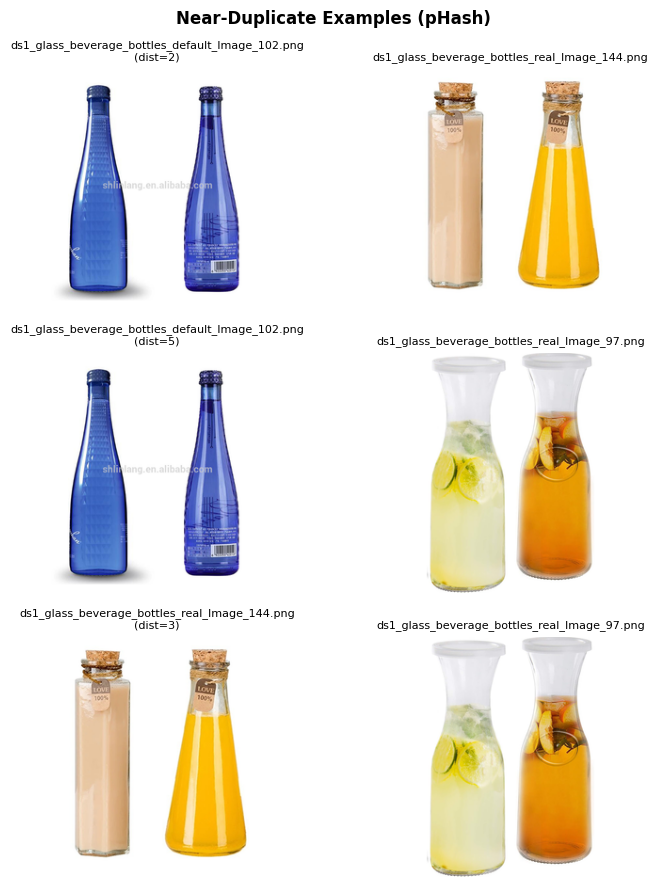

In [37]:
# ═══════════════════════════════════════════════════════
# 1.2  NEAR-DUPLICATE — Perceptual Hash (pHash)
# MD5 chỉ bắt ảnh giống hệt byte. pHash bắt ảnh giống về
# mặt thị giác dù khác kích thước / nhẹ JPEG compression.
# DS2 thu thập từ web nên hay có dạng này.
# ═══════════════════════════════════════════════════════
def compute_phash(img_path: Path, hash_size: int = 8) -> int:
    """
    Perceptual hash: thu nhỏ về (hash_size+1)×hash_size,
    chuyển grayscale, so sánh pixel liền kề → bit string.
    """
    img = Image.open(img_path).convert('L').resize(
        (hash_size + 1, hash_size), Image.LANCZOS
    )
    arr = np.array(img)
    diff = arr[:, 1:] > arr[:, :-1]  # So sánh pixel liền kề
    return sum([2**i for i, v in enumerate(diff.flatten()) if v])

def hamming_distance(h1: int, h2: int) -> int:
    return bin(h1 ^ h2).count('1')

def find_near_dups(data_dir: Path, threshold: int = 5, sample_per_class: int = None):
    """
    threshold: Hamming distance <= threshold → coi là near-duplicate.
    threshold=0: giống hệt về visual.
    threshold=5: cho phép nhỏ sai khác (crop nhẹ, nén khác).
    sample_per_class: Nếu set, chỉ lấy N ảnh mỗi class để test nhanh.
    """
    all_imgs = list(data_dir.rglob('*'))
    all_imgs = [p for p in all_imgs if p.suffix.lower() in IMAGE_EXTS]

    if sample_per_class:
        sampled = []
        for cls in CLASSES:
            cls_imgs = [p for p in all_imgs if cls in str(p)]
            sampled.extend(random.sample(cls_imgs, min(sample_per_class, len(cls_imgs))))
        all_imgs = sampled

    print(f"Tính pHash cho {len(all_imgs)} ảnh...")
    hashes = {}
    for path in tqdm(all_imgs, desc='pHash'):
        try:
            hashes[path] = compute_phash(path)
        except Exception:
            pass

    # So sánh pairwise trong từng class (O(n^2) per class)
    near_dup_pairs = []
    paths_list = list(hashes.keys())

    # Nhóm theo class để giảm complexity
    class_groups = defaultdict(list)
    for p in paths_list:
        cls = p.parent.name
        class_groups[cls].append(p)

    for cls, cls_paths in class_groups.items():
        for i in range(len(cls_paths)):
            for j in range(i + 1, len(cls_paths)):
                d = hamming_distance(hashes[cls_paths[i]], hashes[cls_paths[j]])
                if d <= threshold:
                    near_dup_pairs.append((cls_paths[i], cls_paths[j], d))

    print(f"Near-duplicate pairs (threshold={threshold}): {len(near_dup_pairs)}")
    return near_dup_pairs

# ── CHẠY (sample_per_class để test nhanh) ──
# Khi chạy thật, bỏ sample_per_class để scan toàn bộ
print("=== NEAR-DUPLICATE (pHash) ===")
near_dup_pairs = find_near_dups(DATA_DIR, threshold=5, sample_per_class=100)

if near_dup_pairs:
    print("\nMẫu cặp near-duplicate:")
    for p1, p2, d in near_dup_pairs[:3]:
        print(f"  dist={d}: {p1.name}  ←→  {p2.name}")

    # Visualize 2 cặp gần giống nhau nhất
    fig, axes = plt.subplots(min(3, len(near_dup_pairs)), 2, figsize=(8, min(3, len(near_dup_pairs)) * 3))
    if len(near_dup_pairs) == 1:
        axes = [axes]
    for i, (p1, p2, d) in enumerate(near_dup_pairs[:3]):
        axes[i][0].imshow(Image.open(p1))
        axes[i][0].set_title(f'{p1.name}\n(dist={d})', fontsize=8)
        axes[i][0].axis('off')
        axes[i][1].imshow(Image.open(p2))
        axes[i][1].set_title(p2.name, fontsize=8)
        axes[i][1].axis('off')
    plt.suptitle('Near-Duplicate Examples (pHash)', fontweight='bold')
    plt.tight_layout()
    plt.show()

=== LOW-CONTENT FILTER ===


Low-content scan: 100%|██████████| 20700/20700 [02:05<00:00, 164.87it/s]


Ảnh low-content (std < 10.0): 36
             count  mean   std   min   25%   50%   75%   max
class                                                       
Electronics    2.0  7.18  2.15  5.66  6.42  7.18  7.94  8.70
Glass          3.0  7.50  0.35  7.10  7.38  7.67  7.70  7.74
Paper         21.0  6.59  2.11  2.97  4.74  7.14  8.31  9.76
Plastic       10.0  7.96  0.98  6.47  7.41  7.60  8.76  9.53


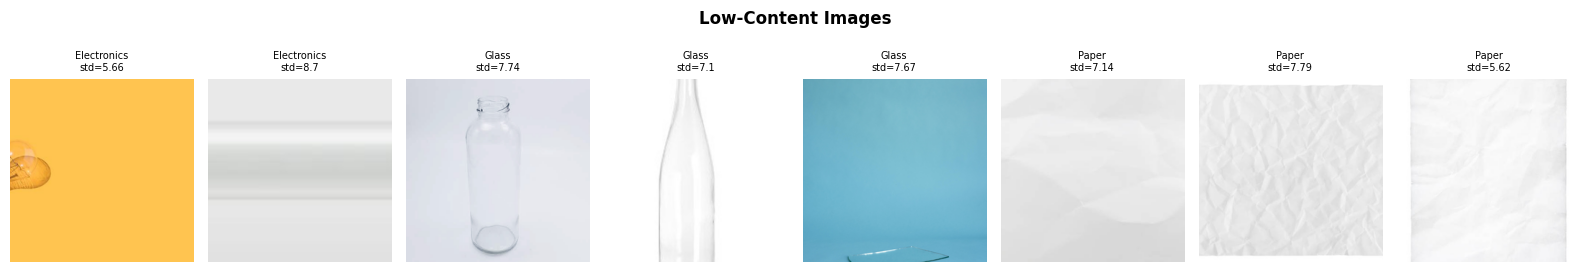

In [38]:
# ═══════════════════════════════════════════════════════
# 1.3  LOW-CONTENT FILTER
# EDA phát hiện Paper có complexity min=5.54 — ảnh giấy
# trắng trên nền trắng gần như không có thông tin.
# Dùng std pixel grayscale làm proxy cho information content.
# ═══════════════════════════════════════════════════════

# Ngưỡng dựa trên EDA: std < 10 → gần như đồng đều hoàn toàn
LOW_CONTENT_THRESHOLD = 10.0

def find_low_content_images(data_dir: Path, threshold: float = LOW_CONTENT_THRESHOLD):
    low_content = []
    all_imgs = list(data_dir.rglob('*'))
    all_imgs = [p for p in all_imgs if p.suffix.lower() in IMAGE_EXTS]

    for path in tqdm(all_imgs, desc='Low-content scan'):
        try:
            gray = np.array(Image.open(path).convert('L'))
            std  = gray.std()
            if std < threshold:
                low_content.append({
                    'path'     : path,
                    'class'    : path.parent.name,
                    'std'      : round(std, 2)
                })
        except Exception:
            pass

    df_lc = pd.DataFrame(low_content)
    if len(df_lc):
        print(f"Ảnh low-content (std < {threshold}): {len(df_lc)}")
        print(df_lc.groupby('class')['std'].describe().round(2))
    else:
        print(f"Không có ảnh low-content nào (threshold={threshold}).")
    return df_lc

print("=== LOW-CONTENT FILTER ===")
df_low = find_low_content_images(DATA_DIR)

# Visualize ảnh low-content (nếu có)
if len(df_low) > 0:
    n_show = min(8, len(df_low))
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 2, 3))
    for i, (_, row) in enumerate(df_low.head(n_show).iterrows()):
        axes[i].imshow(Image.open(row['path']).convert('RGB'))
        axes[i].set_title(f"{row['class']}\nstd={row['std']}", fontsize=7)
        axes[i].axis('off')
    plt.suptitle('Low-Content Images', fontweight='bold')
    plt.tight_layout()
    plt.show()

=== BLUR DETECTION ===


Blur detection: 100%|██████████| 20700/20700 [02:13<00:00, 154.58it/s]


Ảnh mờ (Laplacian var < 20.0): 134
class
Electronics    27
Glass           8
Metal           4
Organic         1
Other           0
Paper          24
Plastic        70
Textiles        0


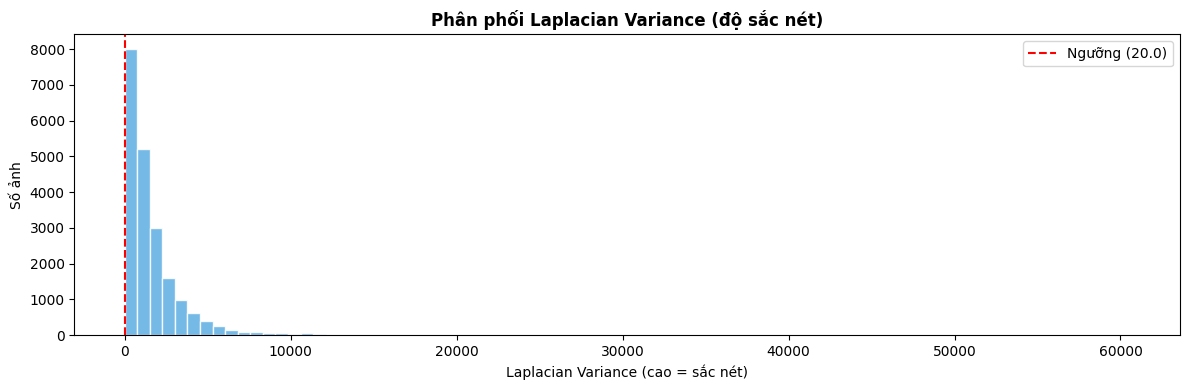

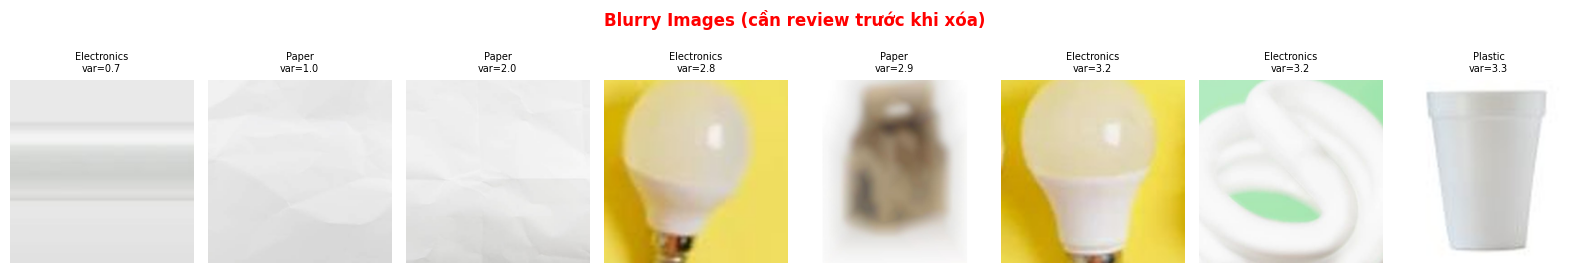

In [39]:
# ═══════════════════════════════════════════════════════
# 1.4  BLUR DETECTION — Laplacian Variance
# Ảnh rác thực tế (DS2) có thể bị nhòe do chụp tay.
# Laplacian variance thấp → ít cạnh sắc → ảnh mờ.
#
# LƯU Ý: Dataset đã 256×256, ảnh studio nên ngưỡng cần thấp.
# Khuyến nghị threshold=20 (thay vì 100 thông thường).
# Nên xem visualize trước khi quyết định xóa.
# ═══════════════════════════════════════════════════════

BLUR_THRESHOLD = 20.0  # Điều chỉnh sau khi xem phân phối

def compute_laplacian_var(img_path: Path) -> float:
    img  = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return -1.0
    return float(cv2.Laplacian(img, cv2.CV_64F).var())

def find_blurry_images(data_dir: Path, threshold: float = BLUR_THRESHOLD):
    results = []
    all_imgs = list(data_dir.rglob('*'))
    all_imgs = [p for p in all_imgs if p.suffix.lower() in IMAGE_EXTS]

    for path in tqdm(all_imgs, desc='Blur detection'):
        lap_var = compute_laplacian_var(path)
        results.append({
            'path'    : path,
            'class'   : path.parent.name,
            'lap_var' : lap_var,
            'is_blurry': lap_var < threshold and lap_var >= 0
        })

    df_blur = pd.DataFrame(results)

    # Phân phối theo class
    print(f"Ảnh mờ (Laplacian var < {threshold}): {df_blur['is_blurry'].sum()}")
    print(df_blur.groupby('class')['is_blurry'].sum().to_string())

    # Histogram phân phối
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(df_blur[df_blur['lap_var'] >= 0]['lap_var'],
            bins=80, color='#5DADE2', edgecolor='white', alpha=0.85)
    ax.axvline(threshold, color='red', linestyle='--', label=f'Ngưỡng ({threshold})')
    ax.set_title('Phân phối Laplacian Variance (độ sắc nét)', fontweight='bold')
    ax.set_xlabel('Laplacian Variance (cao = sắc nét)')
    ax.set_ylabel('Số ảnh')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return df_blur

print("=== BLUR DETECTION ===")
df_blur = find_blurry_images(DATA_DIR)

# Visualize ảnh mờ nhất
df_blurry_sorted = df_blur[df_blur['is_blurry']].sort_values('lap_var').head(8)
if len(df_blurry_sorted):
    fig, axes = plt.subplots(1, len(df_blurry_sorted), figsize=(len(df_blurry_sorted) * 2, 3))
    if len(df_blurry_sorted) == 1: axes = [axes]
    for ax, (_, row) in zip(axes, df_blurry_sorted.iterrows()):
        ax.imshow(Image.open(row['path']))
        ax.set_title(f"{row['class']}\nvar={row['lap_var']:.1f}", fontsize=7)
        ax.axis('off')
    plt.suptitle('Blurry Images (cần review trước khi xóa)', fontweight='bold', color='red')
    plt.tight_layout()
    plt.show()

In [40]:
# ═══════════════════════════════════════════════════════
# 1.5  TỔNG HỢP & COPY DATASET SẠCH
# Sau khi review kết quả trên, chạy cell này để tạo
# Cleaned_Dataset với các ảnh đã lọc.
# ═══════════════════════════════════════════════════════

def build_cleaned_dataset(
    src_dir       : Path,
    dst_dir       : Path,
    dup_groups    : dict,
    df_low        : pd.DataFrame,
    df_blur       : pd.DataFrame,
    remove_blur   : bool = True,   # Chỉ set True sau khi review
    dry_run       : bool = True
):
    """
    Copy ảnh đã lọc sang Cleaned_Dataset.
    dry_run=True: chỉ thống kê, không copy.
    """

    # Tập các path cần LOẠI BỎ
    exclude = set()

    # 1. Exact duplicates: loại bỏ tất cả trừ ảnh đầu tiên (ưu tiên ds1)
    for h, paths in dup_groups.items():
        paths_sorted = sorted(paths, key=lambda p: (0 if 'ds1_' in p.name else 1, p.name))
        for p in paths_sorted[1:]:
            exclude.add(p)

    # 2. Low-content
    if len(df_low):
        for p in df_low['path']:
            exclude.add(Path(p))

    # 3. Blurry (tùy chọn)
    if remove_blur and len(df_blur):
        for _, row in df_blur[df_blur['is_blurry']].iterrows():
            exclude.add(Path(row['path']))

    print(f"Tổng ảnh bị loại: {len(exclude)}")

    # Copy ảnh còn lại
    all_imgs = list(src_dir.rglob('*'))
    all_imgs = [p for p in all_imgs if p.suffix.lower() in IMAGE_EXTS]
    keep = [p for p in all_imgs if p not in exclude]

    print(f"Ảnh giữ lại     : {len(keep)} / {len(all_imgs)}")

    if not dry_run:
        if dst_dir.exists():
            shutil.rmtree(dst_dir)
        for src_path in tqdm(keep, desc='Copy cleaned dataset'):
            # Giữ nguyên cấu trúc class
            rel   = src_path.relative_to(src_dir)
            dst   = dst_dir / rel
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst)

        # Thống kê sau cleaning
        print("\n=== THỐNG KÊ SAU CLEANING ===")
        for cls in CLASSES:
            n = len(list((dst_dir / cls).glob('*')))
            print(f"  {cls:<15}: {n}")

    return keep

# CHẠY DRY RUN TRƯỚC
print("=== TỔNG HỢP CLEANING (DRY RUN) ===")
kept_paths = build_cleaned_dataset(
    src_dir     = DATA_DIR,
    dst_dir     = CLEAN_DIR,
    dup_groups  = dup_groups,
    df_low      = df_low,
    df_blur     = df_blur,
    remove_blur = True,
    dry_run     = True   # ← Đổi thành False để thực thi
)

=== TỔNG HỢP CLEANING (DRY RUN) ===
Tổng ảnh bị loại: 3017
Ảnh giữ lại     : 17683 / 20700


---
## BƯỚC 2: Image Transformation

**Quyết định dựa trên EDA:**
- **Resize → 224×224**: Chuẩn cho CNN (ResNet/VGG), đủ chi tiết cho HOG
- **KHÔNG gray-scale**: EDA cho thấy màu sắc có discriminative power cao — Other/Electronics tối hơn, Glass xanh hơn, Textiles ấm hơn. Bỏ màu = mất thông tin quý.
- **Normalize**: Dùng mean/std thực tế của dataset (đã tính trong EDA), KHÔNG dùng ImageNet mean (vì domain khác biệt rõ).

In [41]:
# ═══════════════════════════════════════════════════════
# 2.1  RESIZE & NORMALIZE
# ═══════════════════════════════════════════════════════

def preprocess_image(
    img_path    : Path,
    size        : int  = TARGET_SIZE,
    normalize   : bool = True,
    return_array: bool = True
) -> np.ndarray:
    """
    Đọc ảnh → resize → normalize về [0,1] với dataset mean/std.
    Trả về numpy array (H, W, 3) float32.
    """
    img = Image.open(img_path).convert('RGB')
    img = img.resize((size, size), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0

    if normalize:
        mean = np.array(DATASET_MEAN, dtype=np.float32)
        std  = np.array(DATASET_STD,  dtype=np.float32)
        arr  = (arr - mean) / (std + 1e-7)

    return arr

# ── Albumentations transform (dùng khi train deep model) ──
# Tách riêng train / val transforms
if ALBU_AVAILABLE:
    train_ops = [
        A.Resize(TARGET_SIZE, TARGET_SIZE),
        A.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
    ]
    val_ops = [
        A.Resize(TARGET_SIZE, TARGET_SIZE),
        A.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
    ]
    if ToTensorV2 is not None:
        train_ops.append(ToTensorV2())
        val_ops.append(ToTensorV2())
    else:
        print("ToTensorV2 unavailable - transforms output numpy arrays.")

    train_transform = A.Compose(train_ops)
    val_transform = A.Compose(val_ops)
else:
    train_transform = None
    val_transform = None
    print("Albumentations unavailable - train/val transforms disabled.")

# ── Kiểm tra nhanh ──
sample_cls  = CLASSES[0]

def pick_sample_image() -> Path | None:
    search_roots = []
    if CLEAN_DIR.exists():
        search_roots.append(CLEAN_DIR)
    search_roots.append(DATA_DIR)

    for root in search_roots:
        cls_dir = root / sample_cls
        if cls_dir.exists():
            for p in cls_dir.rglob('*'):
                if p.suffix.lower() in IMAGE_EXTS:
                    return p
        for cls in CLASSES:
            cls_dir = root / cls
            if cls_dir.exists():
                for p in cls_dir.rglob('*'):
                    if p.suffix.lower() in IMAGE_EXTS:
                        return p
    return None

sample_img = pick_sample_image()
if sample_img is None:
    raise FileNotFoundError(
        "No images found in CLEAN_DIR or DATA_DIR. "
        "Run Step 1.5 with dry_run=False or verify DATA_DIR path."
    )

sample_arr  = preprocess_image(sample_img)

print(f"Input shape : {np.array(Image.open(sample_img)).shape}")
print(f"Output shape: {sample_arr.shape}")
print(f"Value range : [{sample_arr.min():.3f}, {sample_arr.max():.3f}]")
print(f"Mean per channel: R={sample_arr[:,:,0].mean():.3f} G={sample_arr[:,:,1].mean():.3f} B={sample_arr[:,:,2].mean():.3f}")

Input shape : (256, 256, 3)
Output shape: (224, 224, 3)
Value range : [-3.141, 2.003]
Mean per channel: R=-0.091 G=-0.611 B=-0.942


---
## BƯỚC 3: Feature Extraction

**Ba phương án, dùng kết hợp hoặc chọn 1:**

| Feature | Phù hợp với | Ghi chú |
|---------|------------|----------|
| **HOG** | SVM, kNN | Hình dáng vật thể, cạnh, gradient |
| **Color Histogram** | SVM, kNN | Màu sắc — EDA đã chứng minh phân biệt tốt |
| **CNN Embeddings** | SVM, kNN | Vector đặc trưng sâu, mạnh nhất |

> Khuyến nghị: **HOG + Color Histogram** cho pipeline nhẹ; **CNN Embeddings** nếu muốn accuracy cao hơn.

HOG vector size: 6,084 features


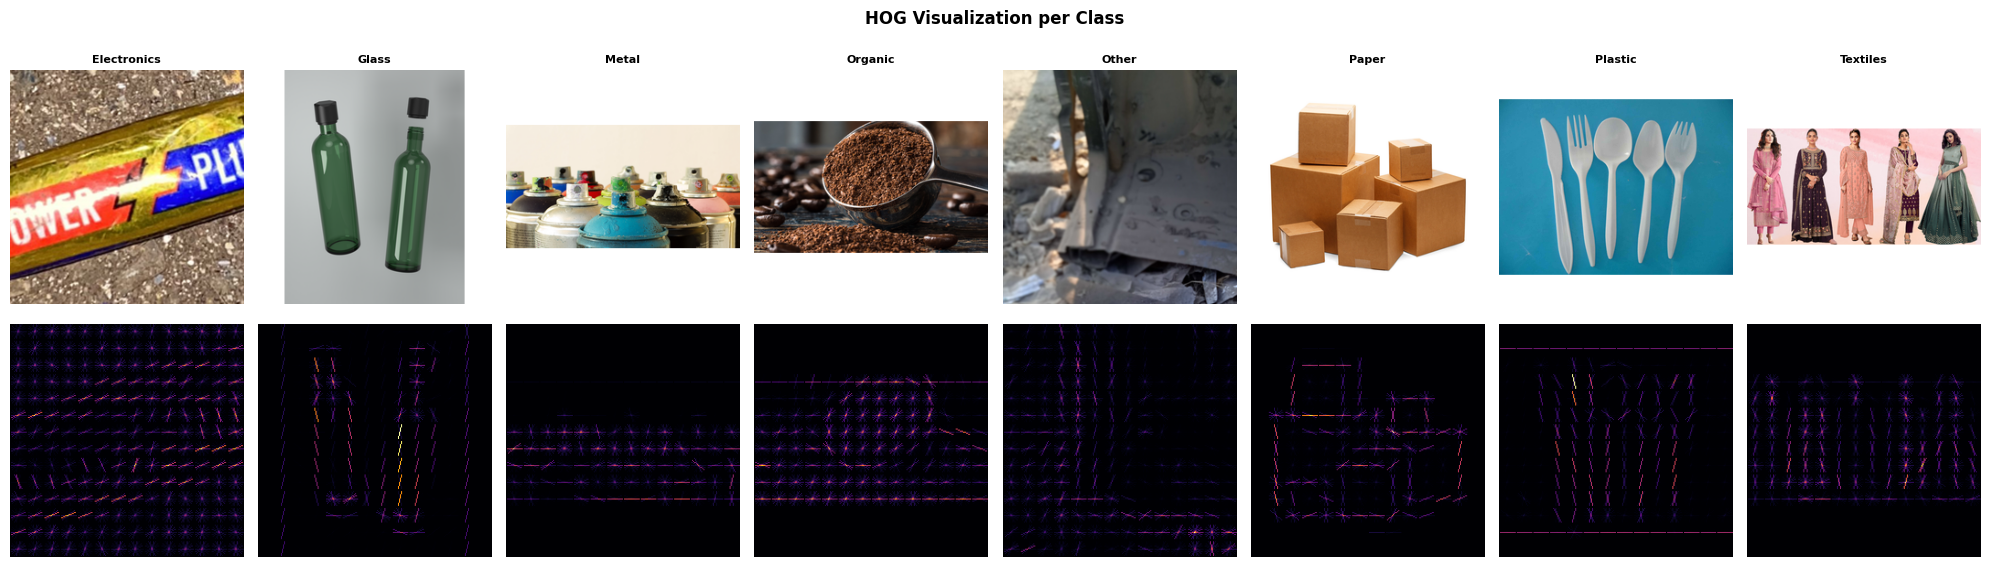

In [42]:
# ═══════════════════════════════════════════════════════
# 3.1  HOG — Histogram of Oriented Gradients
# Nắm bắt hình dáng, cạnh và cấu trúc vật thể.
# Hiệu quả với SVM hơn pixel thô vì invariant với
# thay đổi độ sáng nhỏ.
# ═══════════════════════════════════════════════════════

# Params tối ưu cho ảnh 224×224
HOG_PARAMS = dict(
    orientations  = 9,           # 9 bins góc (0–180°)
    pixels_per_cell = (16, 16),  # Ô nhỏ hơn → chi tiết hơn nhưng nhiều feature hơn
    cells_per_block = (2, 2),    # Block normalization
    channel_axis    = -1,        # RGB input
    transform_sqrt  = True,      # Gamma correction — giúp với ảnh tối (Other/Electronics)
    feature_vector  = True
)

def extract_hog(img_path: Path, size: int = TARGET_SIZE) -> np.ndarray:
    arr = (preprocess_image(img_path, size=size, normalize=False) * 255).astype(np.uint8)
    features = hog(arr, **HOG_PARAMS)
    return features

# ── Test và tính kích thước vector ──
sample_hog = extract_hog(sample_img)
print(f"HOG vector size: {sample_hog.shape[0]:,} features")

# Visualize HOG của 1 ảnh mỗi class
fig, axes = plt.subplots(2, len(CLASSES), figsize=(len(CLASSES) * 2.5, 6))
fig.suptitle('HOG Visualization per Class', fontweight='bold')

def pick_class_image(cls_name: str) -> Path | None:
    for root in (CLEAN_DIR, DATA_DIR):
        if not root.exists():
            continue
        cls_dir = root / cls_name
        if not cls_dir.exists():
            continue
        for p in cls_dir.rglob('*'):
            if p.suffix.lower() in IMAGE_EXTS:
                return p
    return None

for col, cls in enumerate(CLASSES):
    img_path = pick_class_image(cls)
    if img_path is None:
        axes[0][col].text(0.5, 0.5, 'no image', ha='center', va='center', fontsize=8)
        axes[0][col].set_title(cls, fontsize=8, fontweight='bold')
        axes[0][col].axis('off')
        axes[1][col].axis('off')
        continue
    arr      = (preprocess_image(img_path, normalize=False) * 255).astype(np.uint8)
    _, hog_img = hog(arr, **HOG_PARAMS, visualize=True)
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[0][col].imshow(Image.open(img_path))
    axes[0][col].set_title(cls, fontsize=8, fontweight='bold')
    axes[0][col].axis('off')

    axes[1][col].imshow(hog_img_rescaled, cmap='inferno')
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()

Color Hist vector size: 96 features


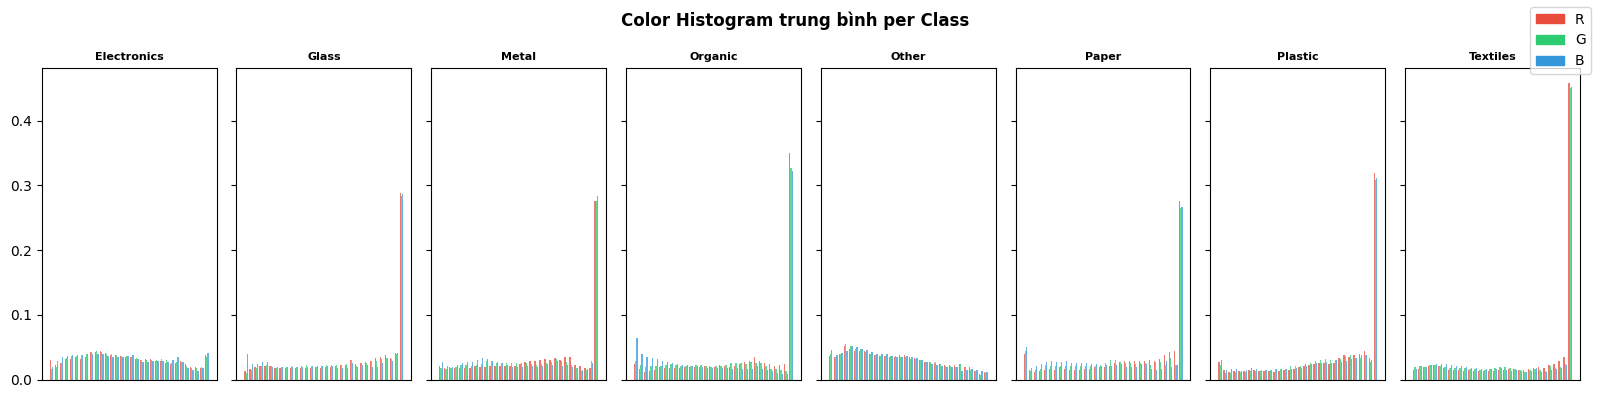

In [43]:
# ═══════════════════════════════════════════════════════
# 3.2  COLOR HISTOGRAM
# EDA chứng minh màu sắc có discriminative power cao:
# - Other/Electronics: tối (R,G,B thấp ~0.4)
# - Textiles: R cao nhất (~0.73)
# - Glass: G cao hơn R một chút
# → Color histogram là đặc trưng đơn giản nhưng mạnh
#   cho bài toán này.
# ═══════════════════════════════════════════════════════

N_BINS = 32  # 32 bins mỗi kênh → 96-dim vector

def extract_color_hist(
    img_path : Path,
    n_bins   : int = N_BINS,
    normalize: bool = True
) -> np.ndarray:
    """
    Trích xuất histogram màu cho từng kênh R, G, B.
    Trả về vector 3*n_bins chiều (normalized).
    """
    img = Image.open(img_path).convert('RGB')
    img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)
    arr = np.array(img)

    hist_features = []
    for channel in range(3):  # R, G, B
        hist, _ = np.histogram(arr[:, :, channel], bins=n_bins, range=(0, 256))
        if normalize:
            hist = hist / (hist.sum() + 1e-7)
        hist_features.append(hist)

    return np.concatenate(hist_features).astype(np.float32)

sample_color = extract_color_hist(sample_img)
print(f"Color Hist vector size: {sample_color.shape[0]} features")

# Visualize histogram màu trung bình per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(len(CLASSES) * 2, 4), sharey=True)
fig.suptitle('Color Histogram trung bình per Class', fontweight='bold')
colors_rgb = ['#E74C3C', '#2ECC71', '#3498DB']
if len(CLASSES) == 1:
    axes = [axes]

def collect_class_images(cls_name: str, max_n: int = 50) -> list[Path]:
    for root in (CLEAN_DIR, DATA_DIR):
        if not root.exists():
            continue
        cls_dir = root / cls_name
        if not cls_dir.exists():
            continue
        imgs = [p for p in cls_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS]
        if imgs:
            return random.sample(imgs, min(max_n, len(imgs)))
    return []

for ax, cls in zip(axes, CLASSES):
    cls_imgs = collect_class_images(cls)
    if not cls_imgs:
        ax.text(0.5, 0.5, 'no image', ha='center', va='center', fontsize=8)
        ax.set_title(cls, fontsize=8, fontweight='bold')
        ax.set_xticks([])
        continue
    hists = np.stack([extract_color_hist(p) for p in cls_imgs], axis=0)
    if hists.ndim != 2 or hists.shape[1] != N_BINS * 3:
        ax.text(0.5, 0.5, 'bad hist', ha='center', va='center', fontsize=8)
        ax.set_title(cls, fontsize=8, fontweight='bold')
        ax.set_xticks([])
        continue
    mean_h = hists.mean(axis=0)

    bins = np.arange(N_BINS)
    for ch, color in enumerate(colors_rgb):
        ax.bar(bins + ch * 0.25, mean_h[ch*N_BINS:(ch+1)*N_BINS],
               width=0.25, color=color, alpha=0.75)
    ax.set_title(cls, fontsize=8, fontweight='bold')
    ax.set_xticks([])

# Legend
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors_rgb, ['R','G','B'])]
fig.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.show()

In [44]:
# ═══════════════════════════════════════════════════════
# 3.3  CNN EMBEDDINGS (ResNet50 — Transfer Learning)
# Dùng ResNet50 pretrained để lấy vector đặc trưng 2048-dim
# rồi dùng làm input cho SVM/kNN.
# Đây là phương án mạnh nhất trong 3 lựa chọn.
# ═══════════════════════════════════════════════════════

if TORCH_AVAILABLE:
    # Load ResNet50, bỏ lớp FC cuối để lấy embeddings
    cnn_model = models.resnet50(weights='IMAGENET1K_V2')
    cnn_model.fc = torch.nn.Identity()  # Bỏ FC → output 2048-dim
    cnn_model.eval()

    cnn_transform = T.Compose([
        T.Resize((TARGET_SIZE, TARGET_SIZE)),
        T.ToTensor(),
        # Dùng dataset mean/std thay vì ImageNet mean/std
        T.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
    ])

    def extract_cnn_embedding(
        img_path : Path,
        model    = cnn_model,
        transform= cnn_transform
    ) -> np.ndarray:
        img    = Image.open(img_path).convert('RGB')
        tensor = transform(img).unsqueeze(0)  # (1, 3, H, W)
        with torch.no_grad():
            emb = model(tensor).squeeze().numpy()  # (2048,)
        return emb.astype(np.float32)

    sample_emb = extract_cnn_embedding(sample_img)
    print(f"CNN Embedding size: {sample_emb.shape[0]:,} features")
else:
    print("Cài PyTorch để dùng CNN embeddings: pip install torch torchvision")

CNN Embedding size: 2,048 features


In [45]:
# ═══════════════════════════════════════════════════════
# 3.4  BUILD FEATURE MATRIX
# Kết hợp HOG + Color Hist (hoặc CNN) → StandardScaler
# → Lưu file .npz để dùng cho SVM/kNN.
# ═══════════════════════════════════════════════════════

FEATURE_MODE = 'hog+color'  # Chọn: 'hog+color' hoặc 'cnn' hoặc 'hog+color+cnn'

def build_feature_matrix(
    data_dir: Path,
    mode: str = FEATURE_MODE,
    fallback_dir: Path | None = None
):
    """
    mode: 'hog+color' | 'cnn' | 'hog+color+cnn'
    Trả về: X (N, D), y (N,), label_encoder
    """
    if 'cnn' in mode and not TORCH_AVAILABLE:
        print("[WARN] Torch unavailable - cnn features will be skipped.")

    X_list, y_list = [], []
    le = LabelEncoder()

    def collect_images(root: Path) -> list[tuple[Path, str]]:
        items = []
        if not root.exists():
            return items
        for cls in CLASSES:
            cls_dir = root / cls
            if not cls_dir.exists():
                continue
            cls_imgs = [p for p in cls_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS]
            for p in cls_imgs:
                items.append((p, cls))
        return items

    all_imgs = collect_images(data_dir)
    if not all_imgs and fallback_dir is not None and fallback_dir != data_dir:
        print(f"[WARN] No images in {data_dir}, fallback to {fallback_dir}")
        all_imgs = collect_images(fallback_dir)
        data_dir = fallback_dir

    if not all_imgs:
        raise FileNotFoundError(
            f"No images found in {data_dir}. "
            "Run Step 1.5 with dry_run=False or verify dataset paths."
        )

    for img_path, cls in tqdm(all_imgs, desc=f'Extracting [{mode}]'):
        feats = []
        try:
            if 'hog' in mode:
                feats.append(extract_hog(img_path))
            if 'color' in mode:
                feats.append(extract_color_hist(img_path))
            if 'cnn' in mode and TORCH_AVAILABLE:
                feats.append(extract_cnn_embedding(img_path))

            if feats:
                X_list.append(np.concatenate(feats))
                y_list.append(cls)
        except Exception as e:
            print(f"  [SKIP] {img_path.name}: {e}")

    if not X_list:
        raise ValueError(
            "No features extracted. Check FEATURE_MODE, Torch availability, and dataset paths."
        )

    X = np.array(X_list, dtype=np.float32)
    y = np.array(le.fit_transform(y_list))

    print(f"Feature matrix: {X.shape}")
    print(f"Classes: {list(zip(le.classes_, range(len(le.classes_))))}")

    # StandardScaler (bắt buộc cho SVM)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, le, scaler

# ── CHẠY ──
X, y, le, scaler = build_feature_matrix(
    CLEAN_DIR, mode=FEATURE_MODE, fallback_dir=DATA_DIR
 )

# Train / Val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Lưu features
FEAT_DIR.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    FEAT_DIR / f'features_{FEATURE_MODE}.npz',
    X_train=X_train, X_val=X_val,
    y_train=y_train, y_val=y_val
)
print(f"\nĐã lưu features → {FEAT_DIR}/features_{FEATURE_MODE}.npz")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

[WARN] No images in Cleaned_Dataset\train, fallback to train


Extracting [hog+color]: 100%|██████████| 20700/20700 [28:49<00:00, 11.97it/s]


Feature matrix: (20700, 6180)
Classes: [(np.str_('Electronics'), 0), (np.str_('Glass'), 1), (np.str_('Metal'), 2), (np.str_('Organic'), 3), (np.str_('Other'), 4), (np.str_('Paper'), 5), (np.str_('Plastic'), 6), (np.str_('Textiles'), 7)]

Đã lưu features → Features/features_hog+color.npz
X_train: (16560, 6180), X_val: (4140, 6180)


---
## BƯỚC 4: Xử lý Class Imbalance

**Vấn đề (từ EDA):** Imbalance ratio 7.12× — Plastic 5692 vs Textiles 800  
**Chiến lược kết hợp:**
1. **Data Augmentation** (chỉ cho class thiếu) — tạo thêm ảnh mới
2. **Class Weights** — penalize model khi sai trên class ít

> Focal Loss (đã mention trong EDA) áp dụng khi dùng deep learning.  
> Với SVM/kNN: dùng `class_weight='balanced'` trong sklearn.

In [46]:
# ═══════════════════════════════════════════════════════
# 4.1  DATA AUGMENTATION cho class ít ảnh
#
# EDA: Background phức tạp ở tất cả class → nguy cơ
# học nhầm background. Augmentation mạnh giúp giảm rủi ro.
#
# CHÚ Ý các lựa chọn augmentation dựa trên EDA:
# - RandomCrop: giúp model học vật thể ở vị trí khác nhau,
#   giảm background dependency
# - ColorJitter/HueSaturation: domain shift DS1 vs DS2
# - RandomBrightnessContrast: F=59 brightness difference giữa classes
# - KHÔNG dùng vertical flip cho rác (trọng lực!)
# ═══════════════════════════════════════════════════════

from PIL import ImageEnhance, ImageOps

# Target: cân bằng về mức tối thiểu TARGET_PER_CLASS
TARGET_PER_CLASS = 2500  # Mức cân bằng thực tế (không underfit, không overfit)

def pil_random_resized_crop(
    img: Image.Image,
    scale=(0.7, 1.0),
    ratio=(0.75, 1.33),
    size: int = TARGET_SIZE
) -> Image.Image:
    w, h = img.size
    area = w * h
    for _ in range(10):
        target_area = random.uniform(*scale) * area
        aspect = random.uniform(*ratio)
        new_w = int(round((target_area * aspect) ** 0.5))
        new_h = int(round((target_area / aspect) ** 0.5))
        if 0 < new_w <= w and 0 < new_h <= h:
            left = random.randint(0, w - new_w)
            top = random.randint(0, h - new_h)
            img = img.crop((left, top, left + new_w, top + new_h))
            return img.resize((size, size), Image.LANCZOS)

    min_side = min(w, h)
    left = (w - min_side) // 2
    top = (h - min_side) // 2
    img = img.crop((left, top, left + min_side, top + min_side))
    return img.resize((size, size), Image.LANCZOS)

def pil_add_noise(img: Image.Image, sigma_range=(10, 25)) -> Image.Image:
    arr = np.array(img).astype(np.float32)
    sigma = random.uniform(*sigma_range)
    noise = np.random.normal(0, sigma, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def pil_augment(img: Image.Image, strength: str = "strong") -> Image.Image:
    if strength == "strong":
        img = pil_random_resized_crop(img, scale=(0.7, 1.0), ratio=(0.75, 1.33))
    else:
        img = pil_random_resized_crop(img, scale=(0.85, 1.0), ratio=(0.9, 1.1))

    if random.random() < 0.5:
        img = ImageOps.mirror(img)

    if strength == "strong":
        if random.random() < 0.7:
            img = ImageEnhance.Brightness(img).enhance(1 + random.uniform(-0.3, 0.3))
        if random.random() < 0.7:
            img = ImageEnhance.Contrast(img).enhance(1 + random.uniform(-0.3, 0.3))
        if random.random() < 0.5:
            img = ImageEnhance.Color(img).enhance(1 + random.uniform(-0.3, 0.3))
        if random.random() < 0.5:
            img = img.rotate(random.uniform(-30, 30), resample=Image.BILINEAR, expand=True)
        if random.random() < 0.3:
            img = pil_add_noise(img)
    else:
        if random.random() < 0.4:
            img = ImageEnhance.Brightness(img).enhance(1 + random.uniform(-0.15, 0.15))
        if random.random() < 0.4:
            img = ImageEnhance.Contrast(img).enhance(1 + random.uniform(-0.15, 0.15))
        if random.random() < 0.3:
            img = ImageEnhance.Color(img).enhance(1 + random.uniform(-0.15, 0.15))
        if random.random() < 0.3:
            img = img.rotate(random.uniform(-10, 10), resample=Image.BILINEAR, expand=True)

    img = ImageOps.fit(img, (TARGET_SIZE, TARGET_SIZE), method=Image.LANCZOS, centering=(0.5, 0.5))
    return img

# Augmentation pipeline
if ALBU_AVAILABLE:
    aug_strong = A.Compose([
        A.RandomResizedCrop(size=(TARGET_SIZE, TARGET_SIZE),
                            scale=(0.7, 1.0), ratio=(0.75, 1.33)),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.5),
        A.GaussNoise(var_limit=(10, 50), p=0.3),          # Simulate DS2 noise
        A.Rotate(limit=30, p=0.5),
        A.Perspective(scale=(0.05, 0.1), p=0.3),          # Simulate góc chụp khác
        A.OneOf([
            A.MotionBlur(blur_limit=3),
            A.GaussianBlur(blur_limit=(3, 5)),
        ], p=0.2),
        A.Resize(TARGET_SIZE, TARGET_SIZE),
    ])

    aug_light = A.Compose([
        A.RandomResizedCrop(size=(TARGET_SIZE, TARGET_SIZE), scale=(0.85, 1.0)),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.3),
        A.Resize(TARGET_SIZE, TARGET_SIZE),
    ])
else:
    print("Albumentations unavailable - using PIL augmentation fallback.")
    def aug_strong(image: Image.Image) -> Image.Image:
        return pil_augment(image, strength="strong")
    def aug_light(image: Image.Image) -> Image.Image:
        return pil_augment(image, strength="light")

def augment_class(
    cls_dir    : Path,
    dst_dir    : Path,
    target_count: int,
    aug_pipeline,
    dry_run    : bool = True
):
    """
    Tạo ảnh augmented cho 1 class cho đến khi đủ target_count.
    """
    cls_name  = cls_dir.name
    src_imgs  = list(cls_dir.rglob('*'))
    src_imgs  = [p for p in src_imgs if p.suffix.lower() in IMAGE_EXTS]
    n_current = len(src_imgs)
    n_needed  = max(0, target_count - n_current)

    print(f"  {cls_name:<15}: {n_current} ảnh → cần tạo thêm {n_needed}")

    if n_current == 0:
        if dry_run:
            return n_needed
        raise FileNotFoundError(
            f"No source images in {cls_dir}. Run Step 1.5 (dry_run=False) first."
        )

    if dry_run or n_needed == 0:
        return n_needed

    # Tạo thư mục đích và copy ảnh gốc
    dst_cls = dst_dir / cls_name
    dst_cls.mkdir(parents=True, exist_ok=True)
    for p in src_imgs:
        shutil.copy2(p, dst_cls / p.name)

    # Sinh ảnh augmented
    aug_count = 0
    while aug_count < n_needed:
        src = random.choice(src_imgs)
        if ALBU_AVAILABLE:
            arr = np.array(Image.open(src).convert('RGB'))
            result = aug_pipeline(image=arr)
            aug_img = Image.fromarray(result['image'])
        else:
            aug_img = aug_pipeline(Image.open(src).convert('RGB'))

        out_name = f"aug_{aug_count:05d}_{src.name}"
        aug_img.save(dst_cls / out_name)
        aug_count += 1

    print(f"    → Đã tạo {aug_count} ảnh augmented")
    return aug_count

def count_images_by_class(root: Path) -> dict[str, int]:
    counts = {}
    for cls in CLASSES:
        cls_dir = root / cls
        if cls_dir.exists():
            counts[cls] = len([
                p for p in cls_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS
            ])
        else:
            counts[cls] = 0
    return counts

# ── Kiểm tra lượng ảnh cần augment ──
plan_root = CLEAN_DIR if CLEAN_DIR.exists() else DATA_DIR
counts = count_images_by_class(plan_root)

if sum(counts.values()) == 0 and plan_root != DATA_DIR:
    plan_root = DATA_DIR
    counts = count_images_by_class(plan_root)

print("=== KẾ HOẠCH AUGMENTATION ===")
print(f"Target per class: {TARGET_PER_CLASS}\n")
print(f"Planning based on: {plan_root}")

for cls in CLASSES:
    n_imgs    = counts[cls]
    n_needed  = max(0, TARGET_PER_CLASS - n_imgs)
    strategy  = 'STRONG aug' if n_imgs < 1500 else ('LIGHT aug' if n_imgs < TARGET_PER_CLASS else 'No aug needed')
    print(f"  {cls:<15}: {n_imgs:>5} ảnh | cần thêm {n_needed:>4} | {strategy}")

C:\Users\admin\AppData\Local\Temp\ipykernel_27524\1671171338.py:93: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),          # Simulate DS2 noise


=== KẾ HOẠCH AUGMENTATION ===
Target per class: 2500

Planning based on: train
  Electronics    :  2508 ảnh | cần thêm    0 | No aug needed
  Glass          :  2218 ảnh | cần thêm  282 | LIGHT aug
  Metal          :  2824 ảnh | cần thêm    0 | No aug needed
  Organic        :  2042 ảnh | cần thêm  458 | LIGHT aug
  Other          :   866 ảnh | cần thêm 1634 | STRONG aug
  Paper          :  3750 ảnh | cần thêm    0 | No aug needed
  Plastic        :  5692 ảnh | cần thêm    0 | No aug needed
  Textiles       :   800 ảnh | cần thêm 1700 | STRONG aug


In [47]:
# ═══════════════════════════════════════════════════════
# 4.2  CHẠY AUGMENTATION
# ═══════════════════════════════════════════════════════

def run_augmentation(
    src_dir      : Path,
    dst_dir      : Path,
    target_count : int = TARGET_PER_CLASS,
    dry_run      : bool = True
):
    if dst_dir.exists() and not dry_run:
        shutil.rmtree(dst_dir)

    for cls in CLASSES:
        cls_dir = src_dir / cls
        n_imgs  = len(list(cls_dir.rglob('*')))

        # Chọn strength theo số lượng ảnh
        pipeline = aug_strong if n_imgs < 1500 else aug_light

        augment_class(cls_dir, dst_dir, target_count, pipeline, dry_run=dry_run)

    if not dry_run:
        print("\n=== KẾT QUẢ SAU AUGMENTATION ===")
        for cls in CLASSES:
            n = len(list((dst_dir / cls).glob('*')))
            print(f"  {cls:<15}: {n}")

print("=== AUGMENTATION DRY RUN ===")
run_augmentation(CLEAN_DIR, AUG_DIR, dry_run=True)

# Bỏ comment để chạy thật:
# run_augmentation(CLEAN_DIR, AUG_DIR, dry_run=False)

=== AUGMENTATION DRY RUN ===
  Electronics    : 0 ảnh → cần tạo thêm 2500
  Glass          : 0 ảnh → cần tạo thêm 2500
  Metal          : 0 ảnh → cần tạo thêm 2500
  Organic        : 0 ảnh → cần tạo thêm 2500
  Other          : 0 ảnh → cần tạo thêm 2500
  Paper          : 0 ảnh → cần tạo thêm 2500
  Plastic        : 0 ảnh → cần tạo thêm 2500
  Textiles       : 0 ảnh → cần tạo thêm 2500


In [48]:
# ═══════════════════════════════════════════════════════
# 4.2b  SAVE CLEANED + AUGMENTED DATASETS
# Lưu ảnh đã lọc vào Cleaned_Dataset và ảnh cân bằng vào Augmented_Dataset.
# ═══════════════════════════════════════════════════════

SAVE_CLEANED = False
SAVE_AUGMENTED = False

def has_images(root: Path) -> bool:
    if not root.exists():
        return False
    for p in root.rglob('*'):
        if p.suffix.lower() in IMAGE_EXTS:
            return True
    return False

if SAVE_CLEANED:
    print("=== BUILD CLEANED DATASET ===")
    build_cleaned_dataset(
        src_dir     = DATA_DIR,
        dst_dir     = CLEAN_DIR,
        dup_groups  = dup_groups,
        df_low      = df_low,
        df_blur     = df_blur,
        remove_blur = True,
        dry_run     = False
    )
else:
    print("Set SAVE_CLEANED = True to write Cleaned_Dataset.")

if SAVE_AUGMENTED:
    if not has_images(CLEAN_DIR):
        raise FileNotFoundError(
            "Cleaned_Dataset not found or empty. Run SAVE_CLEANED first."
        )
    print("=== RUN AUGMENTATION ===")
    run_augmentation(CLEAN_DIR, AUG_DIR, dry_run=False)
else:
    print("Set SAVE_AUGMENTED = True to write Augmented_Dataset.")

Set SAVE_CLEANED = True to write Cleaned_Dataset.
Set SAVE_AUGMENTED = True to write Augmented_Dataset.


In [49]:
# ═══════════════════════════════════════════════════════
# 4.3  CLASS WEIGHTS
# Dùng cho SVM: class_weight='balanced'
# Dùng cho PyTorch: truyền vào CrossEntropyLoss hoặc Focal Loss
# ═══════════════════════════════════════════════════════

# Tính class weights từ Cleaned_Dataset (fallback DATA_DIR nếu chưa có)
def count_images_by_class(root: Path) -> dict[str, int]:
    counts = {}
    for cls in CLASSES:
        cls_dir = root / cls
        if cls_dir.exists():
            counts[cls] = len([
                p for p in cls_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS
            ])
        else:
            counts[cls] = 0
    return counts

root_for_weights = CLEAN_DIR if CLEAN_DIR.exists() else DATA_DIR
counts = count_images_by_class(root_for_weights)

# Nếu Cleaned_Dataset rỗng, tự động fallback về DATA_DIR
if sum(counts.values()) == 0 and root_for_weights != DATA_DIR:
    root_for_weights = DATA_DIR
    counts = count_images_by_class(root_for_weights)

missing = [cls for cls, n in counts.items() if n == 0]
if missing:
    raise ValueError(
        "No images for classes in "
        f"{root_for_weights}: {missing}. "
        "Run Step 1.5 (dry_run=False) or verify dataset paths."
    )

print(f"Using dataset for class weights: {root_for_weights}")

all_labels_for_weights = []
for cls_idx, cls in enumerate(CLASSES):
    all_labels_for_weights.extend([cls_idx] * counts[cls])

all_labels_for_weights = np.array(all_labels_for_weights, dtype=int)

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.arange(len(CLASSES)),
    y            = all_labels_for_weights
)

class_weight_dict = dict(zip(range(len(CLASSES)), class_weights))

print("=== CLASS WEIGHTS (balanced) ===")
for cls, w in zip(CLASSES, class_weights):
    bar = '█' * int(w * 5)
    print(f"  {cls:<15}: {w:.4f}  {bar}")

print("\nSử dụng:")
print("  SVM   : SVC(..., class_weight='balanced')")
print("  kNN   : không hỗ trợ trực tiếp → dùng sample_weight khi evaluate")
print("  PyTorch: weight = torch.tensor(class_weights, dtype=torch.float)")
print("           loss = nn.CrossEntropyLoss(weight=weight)")

# Lưu class weights
FEAT_DIR.mkdir(parents=True, exist_ok=True)
np.save(FEAT_DIR / 'class_weights.npy', class_weights)
with open(FEAT_DIR / 'label_map.json', 'w') as f:
    json.dump(dict(zip(CLASSES, range(len(CLASSES)))), f, indent=2)

print(f"\nĐã lưu class_weights.npy và label_map.json → {FEAT_DIR}/")

Using dataset for class weights: train
=== CLASS WEIGHTS (balanced) ===
  Electronics    : 1.0317  █████
  Glass          : 1.1666  █████
  Metal          : 0.9163  ████
  Organic        : 1.2671  ██████
  Other          : 2.9879  ██████████████
  Paper          : 0.6900  ███
  Plastic        : 0.4546  ██
  Textiles       : 3.2344  ████████████████

Sử dụng:
  SVM   : SVC(..., class_weight='balanced')
  kNN   : không hỗ trợ trực tiếp → dùng sample_weight khi evaluate
  PyTorch: weight = torch.tensor(class_weights, dtype=torch.float)
           loss = nn.CrossEntropyLoss(weight=weight)

Đã lưu class_weights.npy và label_map.json → Features/


---
## TỔNG KẾT PIPELINE

| Bước | Kỹ thuật | Lý do (từ EDA) | Output |
|------|----------|----------------|--------|
| 1.1 | MD5 Dedup | 5.423 ảnh trùng (~26%) | Xóa ảnh trùng |
| 1.2 | pHash Near-dup | DS2 web-scraped có near-dup | Xóa ảnh gần giống |
| 1.3 | Low-Content | Paper min std=5.54 | Xóa ảnh giấy trắng |
| 1.4 | Laplacian Blur | DS2 thực tế có thể nhòe | Xóa ảnh mờ |
| 2 | Resize 224 + Normalize dataset mean | 256→224 chuẩn CNN | `preprocess_image()` |
| 2 | Không gray-scale | Màu sắc discriminative (EDA) | Giữ RGB |
| 3 | HOG + Color Hist | Hình dáng + màu sắc (EDA) | X_train.npz |
| 3 | CNN Embedding | Vector sâu nhất | X_train_cnn.npz |
| 4 | Augmentation strong/light | Imbalance 7.12× | Augmented_Dataset |
| 4 | Class Weights | class_weight='balanced' | class_weights.npy |

In [50]:
# ═══════════════════════════════════════════════════════
# QUICK SUMMARY — In ra toàn bộ thống kê pipeline
# ═══════════════════════════════════════════════════════
print('=' * 55)
print('PREPROCESSING PIPELINE — SUMMARY')
print('=' * 55)

# Ảnh gốc
n_original = sum(
    len(list((DATA_DIR / cls).rglob('*')))
    for cls in CLASSES
)
print(f'Ảnh gốc (sau merge)  : {n_original:,}')

# Sau cleaning
n_cleaned = sum(
    len(list((CLEAN_DIR / cls).rglob('*')))
    for cls in CLASSES
) if CLEAN_DIR.exists() else '(chưa tạo)'
print(f'Sau cleaning         : {n_cleaned}')

# Features
print(f'Feature mode         : {FEATURE_MODE}')
if 'X_train' in dir():
    print(f'X_train shape        : {X_train.shape}')
    print(f'X_val   shape        : {X_val.shape}')

# Class distribution
print(f'\nClass weights (balanced):')
for cls, w in zip(CLASSES, class_weights):
    print(f'  {cls:<15}: {w:.4f}')

print('\nFiles output:')
print(f'  Cleaned_Dataset/  → ảnh đã lọc')
print(f'  Augmented_Dataset/ → ảnh đã cân bằng')
print(f'  Features/         → features .npz + class_weights.npy')

PREPROCESSING PIPELINE — SUMMARY
Ảnh gốc (sau merge)  : 20,700
Sau cleaning         : (chưa tạo)
Feature mode         : hog+color
X_train shape        : (16560, 6180)
X_val   shape        : (4140, 6180)

Class weights (balanced):
  Electronics    : 1.0317
  Glass          : 1.1666
  Metal          : 0.9163
  Organic        : 1.2671
  Other          : 2.9879
  Paper          : 0.6900
  Plastic        : 0.4546
  Textiles       : 3.2344

Files output:
  Cleaned_Dataset/  → ảnh đã lọc
  Augmented_Dataset/ → ảnh đã cân bằng
  Features/         → features .npz + class_weights.npy
